## Import Libraries

In [21]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.pyplot import get_cmap
# Load HMF v3_iter3 data (with mass cut 1e11)
import os
from pathlib import Path
import pandas as pd
import numpy as np
from galform_analysis.config import get_base_dir, get_snapshot_redshift
from galform_analysis.analysis import (
    completed_galaxies,
    avg_hmf_given_redshift_and_subvolumes,
    avg_correlation_given_redshift_and_subvolumes,
)
from galform_analysis.analysis.correlation.correlation import avg_correlation_given_redshift_and_subvolumes


project_root = Path.cwd()
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

base_dir = Path(get_base_dir())

## Filter and Get only Successful subvolume runs

In [22]:
# Resolve repository root
def find_repo_root_hmf():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for p in candidates:
        if (p / "convergence_results_v3_iter3").exists():
            return p
    return Path.cwd().parent.parent

repo_root = find_repo_root_hmf()
v3_dir = str(repo_root / "convergence_results_v3_iter3")

# Load HMF data for iz271
hmf_path_271 = os.path.join(v3_dir, "hmf_convergence_iz271.csv")
if os.path.isfile(hmf_path_271):
    hmf_271 = pd.read_csv(hmf_path_271)
    print(f"✓ Loaded HMF v3_iter3 data for iz271")
    print(f"  Shape: {hmf_271.shape}")
    print(f"  Unique n_ivols: {sorted(hmf_271['n_ivols'].unique())}")
    print(f"  Mass bin range: log10(M) ∈ [{hmf_271['log_Mhalo'].min():.2f}, {hmf_271['log_Mhalo'].max():.2f}]")
    print(f"  Mass cut applied: 1e11 Msun")
else:
    hmf_271 = None
    print("✗ No HMF v3_iter3 data found for iz271")

# Load HMF data for iz207
hmf_path_207 = os.path.join(v3_dir, "hmf_convergence_iz207.csv")
if os.path.isfile(hmf_path_207):
    hmf_207 = pd.read_csv(hmf_path_207)
    print(f"\n✓ Loaded HMF v3_iter3 data for iz207")
    print(f"  Shape: {hmf_207.shape}")
    print(f"  Unique n_ivols: {sorted(hmf_207['n_ivols'].unique())}")
    print(f"  Mass bin range: log10(M) ∈ [{hmf_207['log_Mhalo'].min():.2f}, {hmf_207['log_Mhalo'].max():.2f}]")
else:
    hmf_207 = None
    print("\n✗ No HMF v3_iter3 data found for iz207")


print("hmf207: \n", hmf_207)
print("hmf271: \n", hmf_271)

✓ Loaded HMF v3_iter3 data for iz271
  Shape: (348, 6)
  Unique n_ivols: [1, 2, 4, 8, 10, 15, 20, 30, 50, 100, 200, 1024]
  Mass bin range: log10(M) ∈ [9.10, 14.70]
  Mass cut applied: 1e11 Msun

✓ Loaded HMF v3_iter3 data for iz207
  Shape: (348, 6)
  Unique n_ivols: [1, 2, 4, 8, 10, 15, 20, 30, 50, 100, 200, 1024]
  Mass bin range: log10(M) ∈ [9.10, 14.70]
hmf207: 
         iz         z  n_ivols  log_Mhalo           phi  bin_idx
0    iz207  0.495942        1        9.1  0.000000e+00        0
1    iz207  0.495942        1        9.3  0.000000e+00        1
2    iz207  0.495942        1        9.5  0.000000e+00        2
3    iz207  0.495942        1        9.7  0.000000e+00        3
4    iz207  0.495942        1        9.9  0.000000e+00        4
..     ...       ...      ...        ...           ...      ...
343  iz207  0.495942     1024       13.9  5.409099e-05       24
344  iz207  0.495942     1024       14.1  2.393934e-05       25
345  iz207  0.495942     1024       14.3  8.816454e-0

In [ ]:
# Create hmf_stats_v3 from single iteration data (no averaging needed)
# Since v3 only has one iteration, we just rename phi -> phi_mean for compatibility
if hmf_271 is not None:
    hmf_stats_v3 = hmf_271.copy()
    hmf_stats_v3 = hmf_stats_v3.rename(columns={'phi': 'phi_mean'})
    hmf_stats_v3['phi_std'] = 0.0  # No std for single iteration
    
    print(f"✓ Created hmf_stats_v3 from hmf_271")
    print(f"  Shape: {hmf_stats_v3.shape}")
    print(f"  Unique n_ivols: {sorted(hmf_stats_v3['n_ivols'].unique())}")
    print(f"  Columns: {list(hmf_stats_v3.columns)}")
else:
    hmf_stats_v3 = None
    print("✗ hmf_271 not available")

✓ Created hmf_stats_v3 from hmf_271
  Shape: (348, 7)
  Unique n_ivols: [1, 2, 4, 8, 10, 15, 20, 30, 50, 100, 200, 1024]
  Columns: ['iz', 'z', 'n_ivols', 'log_Mhalo', 'phi_mean', 'bin_idx', 'phi_std']


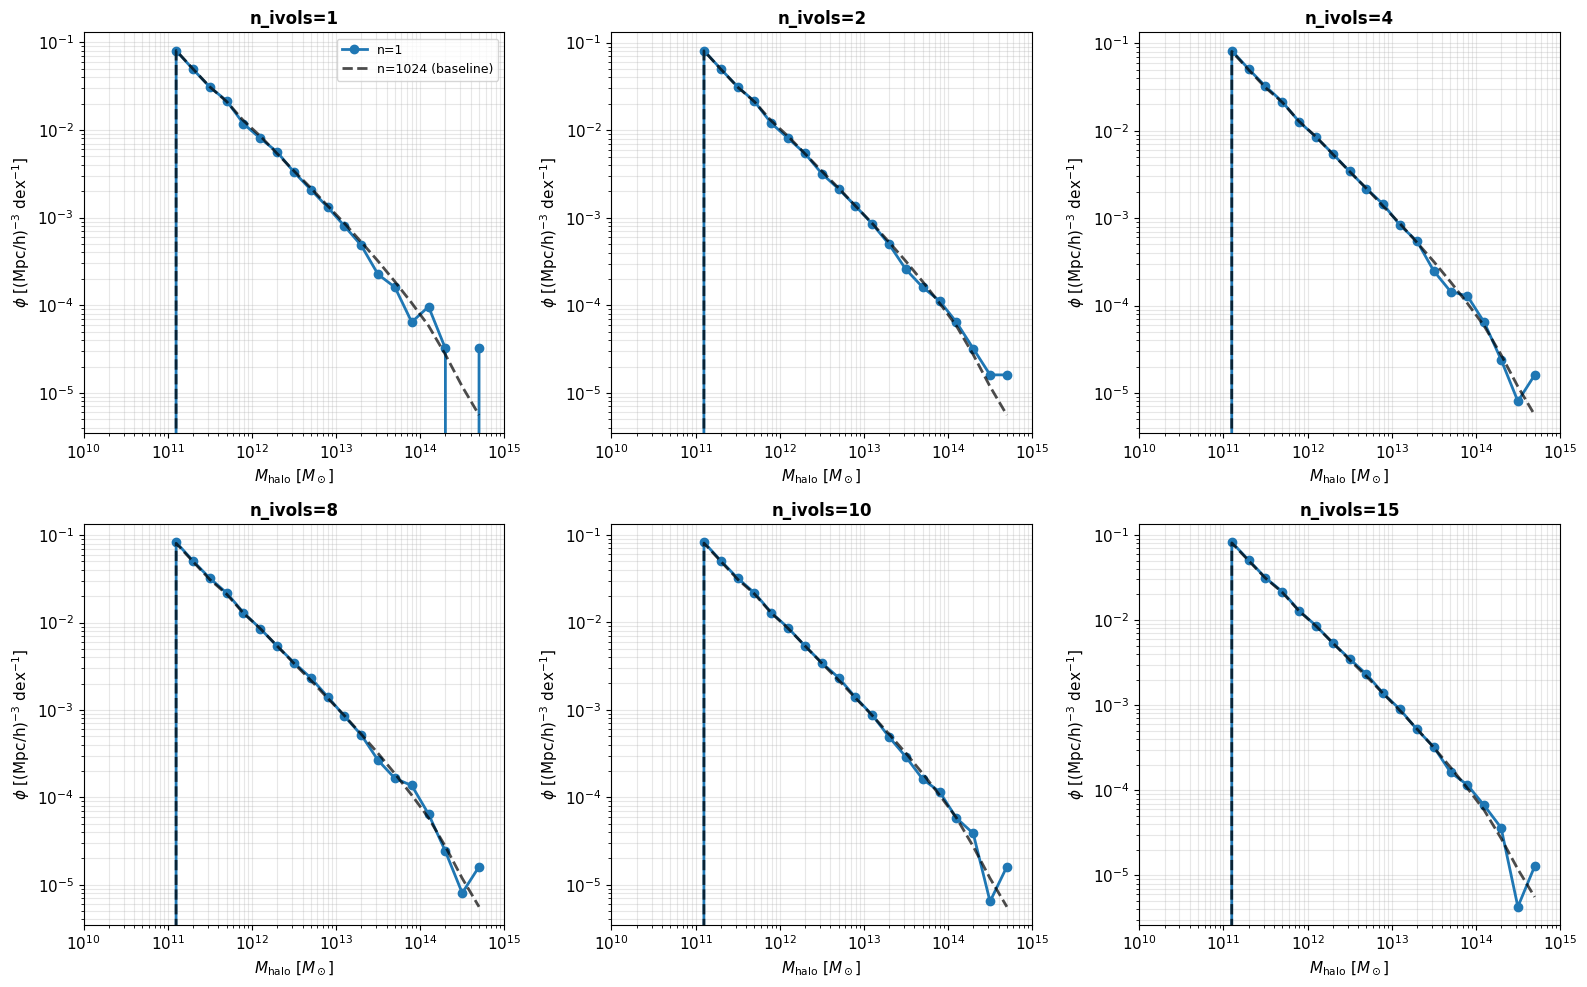

In [45]:
# Plot HMF overlay for iz271 (v3 single iteration)

selected_n_hmf = [1, 2, 4, 8, 10, 15, 20, 30, 50, 100, 200, 1024]
available_n_hmf = sorted(hmf_stats_v3['n_ivols'].unique())
selected_n_hmf = [n for n in selected_n_hmf if n in available_n_hmf]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Get baseline (n=1024)
baseline = hmf_stats_v3[hmf_stats_v3['n_ivols'] == 1024].sort_values('log_Mhalo')

# Plot for first 6 selected n_ivols
for idx, n_val in enumerate(selected_n_hmf[:6]):
    ax: plt.Axes = axes[idx]

    # Get data for this n
    sub = hmf_stats_v3[hmf_stats_v3['n_ivols'] == n_val].sort_values('log_Mhalo')

    # Plot single-iteration curve (no error band)
    M = 10.0 ** sub['log_Mhalo'].values
    phi = sub['phi_mean'].values
    ax.loglog(M, phi, 'o-', linewidth=2, markersize=6, label=f'n={n_val}', color='C0')

    # Overlay baseline
    M_base = 10.0 ** baseline['log_Mhalo'].values
    phi_base = baseline['phi_mean'].values
    ax.loglog(M_base, phi_base, 'k--', linewidth=2, alpha=0.7, label='n=1024 (baseline)')

    ax.set_xlabel(r"$M_{\mathrm{halo}}$ [$M_\odot$]", fontsize=11)
    ax.set_ylabel(r"$\phi$ [(Mpc/h)$^{-3}$ dex$^{-1}$]", fontsize=11)
    ax.set_title(f'n_ivols={n_val}', fontsize=12, fontweight='bold')
    ax.set_xlim(1e10,1e15)
    ax.grid(True, alpha=0.3, which='both')
    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# Compute HMF convergence metrics vs baseline n_ivols=1024
def hmf_scalar_metrics(df, ref_n=1024):
    """Compute convergence metrics vs reference N."""
    if df is None or len(df) == 0 or ref_n not in df['n_ivols'].unique():
        return None
    
    def to_sigfig(val, sig=2):
        return float(f"{val:.{sig}g}") if np.isfinite(val) else val
    
    # Average phi at each n_ivols, bin_idx
    avg = df.groupby(['n_ivols', 'bin_idx'], as_index=False).agg(phi_mean=('phi_mean', 'mean'))
    ref = avg[avg['n_ivols'] == ref_n][['bin_idx', 'phi_mean']].rename(columns={'phi_mean': 'phi_ref'})
    
    merged = avg.merge(ref, on='bin_idx', how='inner')
    merged = merged[merged['n_ivols'] != ref_n].copy()
    
    # Drop bins where reference is zero to avoid infinities
    mask = (merged['phi_ref'] > 0) & (merged['phi_mean'] > 0)
    safe = merged[mask].copy()
    
    if len(safe) == 0:
        return None
    
    safe['rel_err'] = (safe['phi_mean'] - safe['phi_ref']) / safe['phi_ref']
    safe['log10_ratio'] = np.log10(safe['phi_mean'] / safe['phi_ref'])
    
    out = safe.groupby('n_ivols', as_index=False).agg(
        mean_rel_err=('rel_err', lambda x: to_sigfig(np.mean(x), 2)),
        mean_abs_rel_err=('rel_err', lambda x: to_sigfig(np.mean(np.abs(x)), 2)),
        median_abs_rel_err=('rel_err', lambda x: to_sigfig(np.median(np.abs(x)), 2)),
        max_abs_rel_err=('rel_err', lambda x: to_sigfig(np.max(np.abs(x)), 2)),
        rmse_log10_ratio=('log10_ratio', lambda x: to_sigfig(np.sqrt(np.mean(x**2)), 2)),
    ).sort_values('n_ivols')
    
    return out

if hmf_stats_v3 is not None:
    hmf_metrics_v3 = hmf_scalar_metrics(hmf_stats_v3)
    
    if hmf_metrics_v3 is not None:
        z_271 = get_snapshot_redshift("iz271")
        print(f"\nHMF convergence metrics for iz271 (z={z_271:.2f}), baseline n=1024:")
        print("=" * 90)
        print(hmf_metrics_v3.to_string(index=False))
else:
    hmf_metrics_v3 = None
    print("✗ hmf_stats_v3 not available")



HMF convergence metrics for iz271 (z=0.00), baseline n=1024:
 n_ivols  mean_rel_err  mean_abs_rel_err  median_abs_rel_err  max_abs_rel_err  rmse_log10_ratio
       1        0.2400             0.380              0.0630             4.80             0.200
       2        0.1100             0.170              0.0550             1.90             0.110
       4        0.0760             0.170              0.0370             1.90             0.120
       8        0.0920             0.170              0.0330             1.90             0.120
      10        0.0960             0.180              0.0260             1.90             0.130
      15        0.0690             0.150              0.0220             1.30             0.140
      20        0.0061             0.110              0.0150             0.73             0.140
      30       -0.0120             0.083              0.0140             0.64             0.110
      50       -0.0190             0.053              0.0091             0

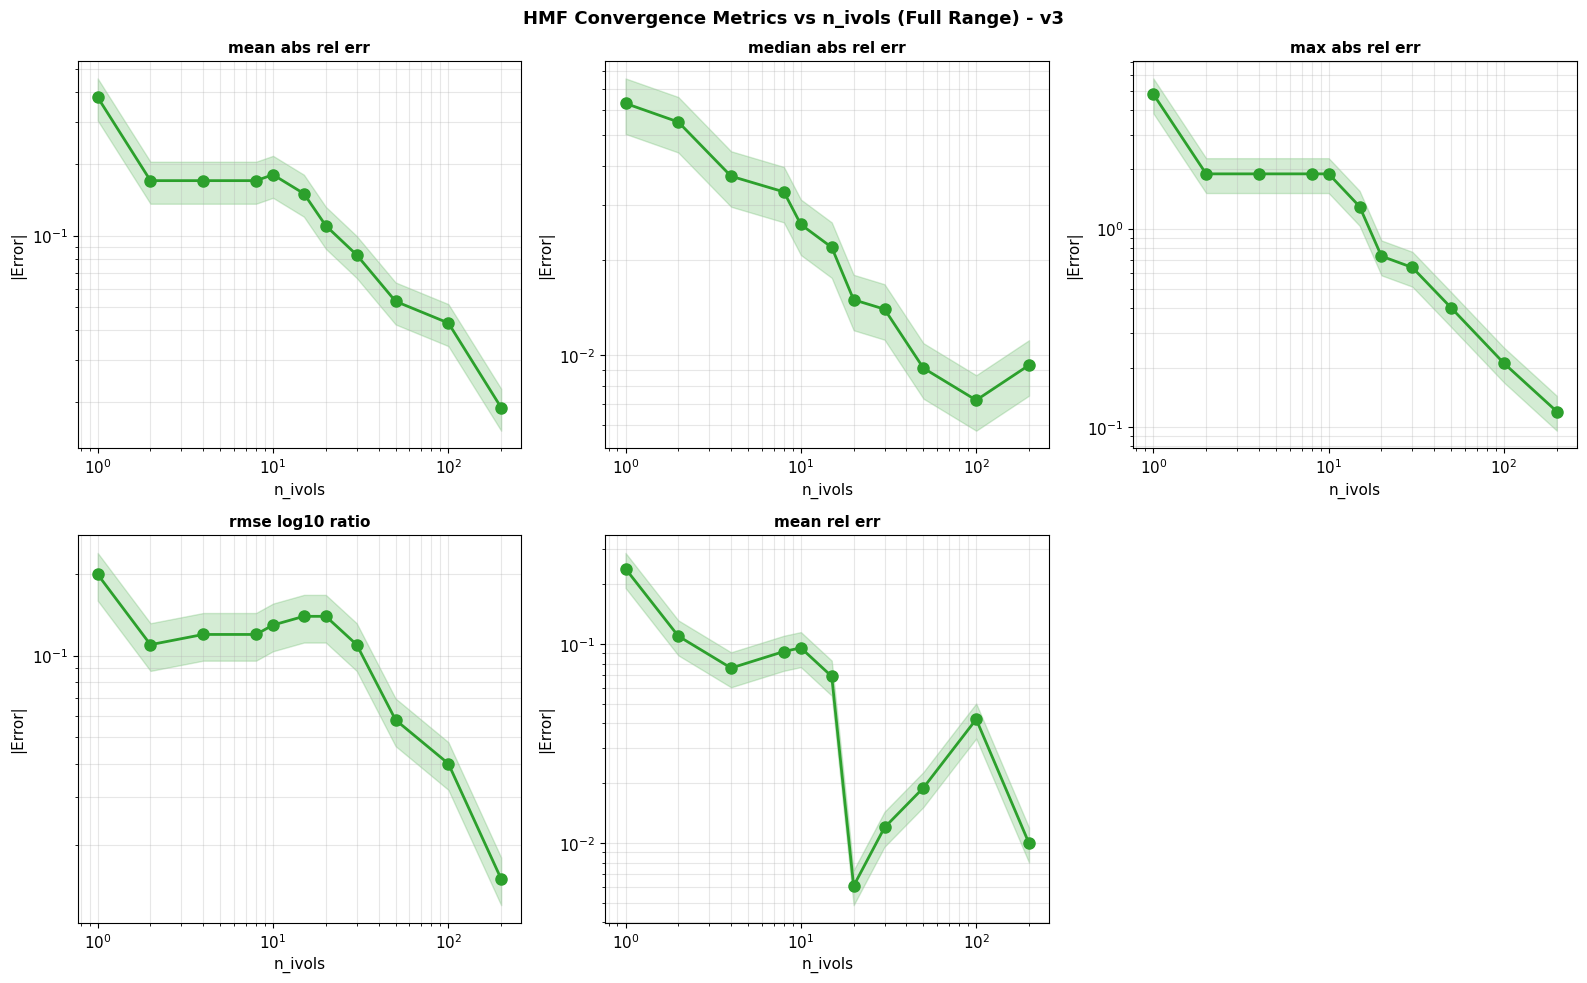

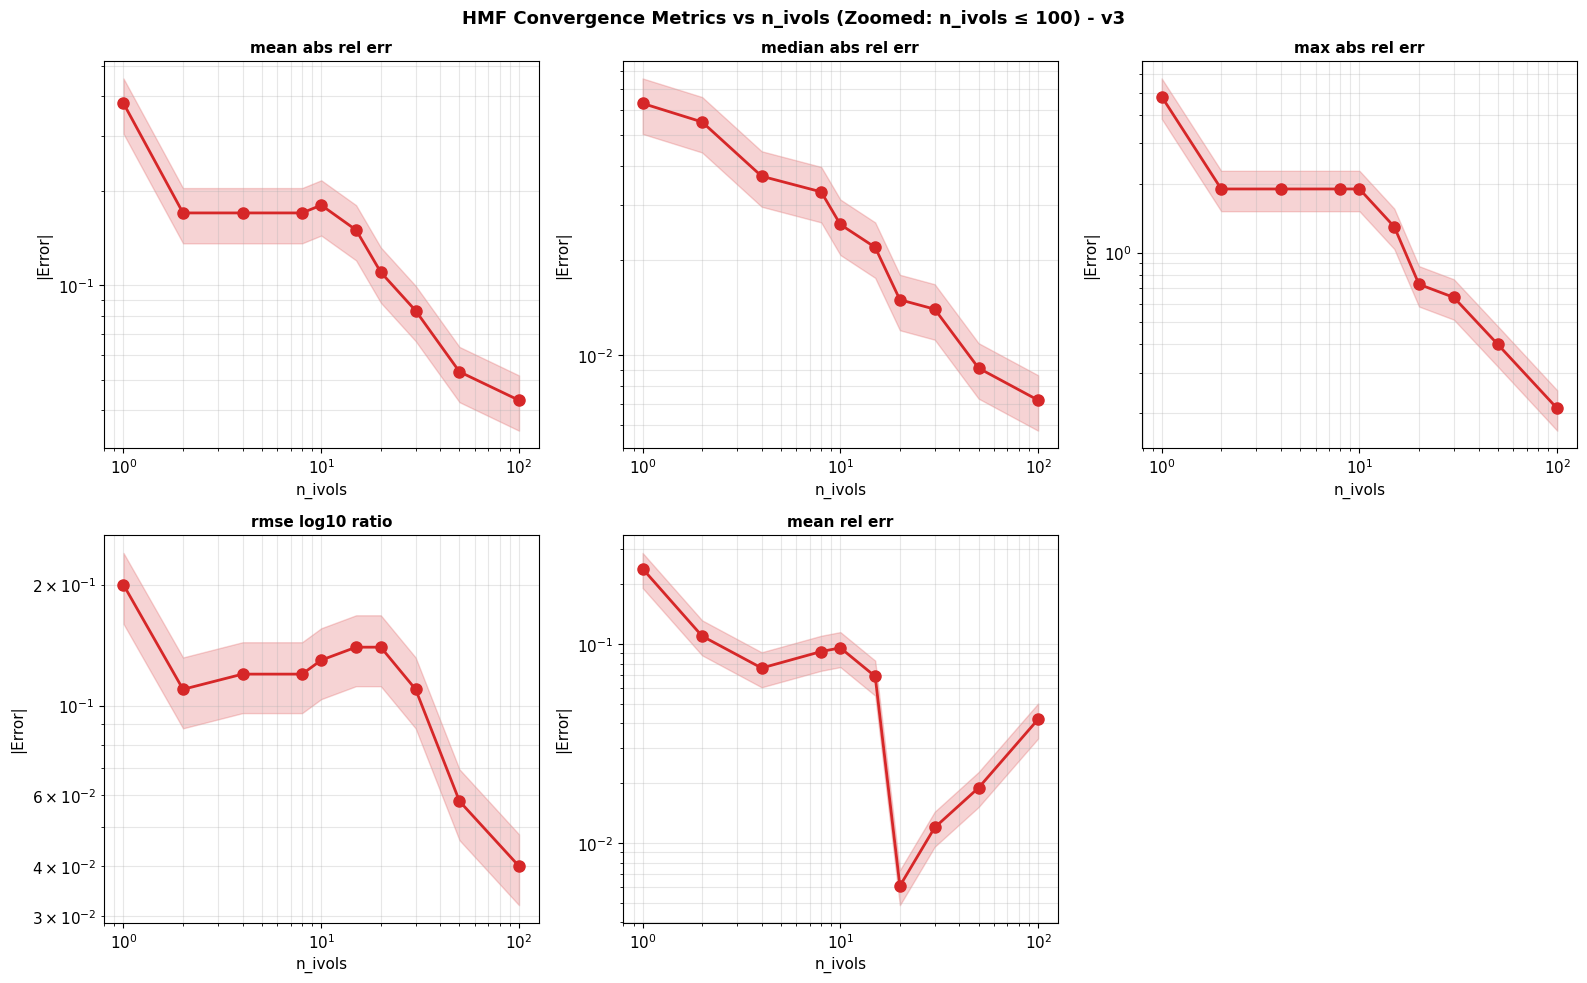

✓ HMF metrics plots generated


In [25]:
# Plot HMF metrics vs n_ivols (full range and zoomed)
if hmf_metrics_v3 is not None:
    metric_cols = [
        'mean_abs_rel_err',
        'median_abs_rel_err', 
        'max_abs_rel_err',
        'rmse_log10_ratio',
        'mean_rel_err',
    ]
    
    # Full range plot
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metric_cols):
        ax = axes[idx]
        data = hmf_metrics_v3.copy()
        data[metric] = pd.to_numeric(data[metric], errors='coerce')
        
        ax.semilogy(data['n_ivols'], np.abs(data[metric]), 'o-', linewidth=2, markersize=8, color='C2')
        ax.fill_between(data['n_ivols'], 
                        np.abs(data[metric]) * 0.8,
                        np.abs(data[metric]) * 1.2,
                        alpha=0.2, color='C2')
        
        ax.set_xlabel('n_ivols', fontsize=11)
        ax.set_ylabel('|Error|', fontsize=11)
        ax.set_title(metric.replace('_', ' '), fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xscale('log')
    
    # Hide unused subplot
    axes[-1].set_visible(False)
    
    fig.suptitle('HMF Convergence Metrics vs n_ivols (Full Range) - v3', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('hmf_v3_metrics_full.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Zoomed plot (n_ivols ≤ 100)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metric_cols):
        ax = axes[idx]
        data = hmf_metrics_v3[hmf_metrics_v3['n_ivols'] <= 100].copy()
        data[metric] = pd.to_numeric(data[metric], errors='coerce')
        
        ax.semilogy(data['n_ivols'], np.abs(data[metric]), 'o-', linewidth=2, markersize=8, color='C3')
        ax.fill_between(data['n_ivols'],
                        np.abs(data[metric]) * 0.8,
                        np.abs(data[metric]) * 1.2,
                        alpha=0.2, color='C3')
        
        ax.set_xlabel('n_ivols', fontsize=11)
        ax.set_ylabel('|Error|', fontsize=11)
        ax.set_title(metric.replace('_', ' '), fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xscale('log')
    
    # Hide unused subplot
    axes[-1].set_visible(False)
    
    fig.suptitle('HMF Convergence Metrics vs n_ivols (Zoomed: n_ivols ≤ 100) - v3', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('hmf_v3_metrics_zoomed.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ HMF metrics plots generated")
else:
    print("✗ hmf_metrics_v3 not available for plotting")


## HMF Metrics vs n_ivols (v3)
Plot convergence metrics showing how quickly HMF converges with increasing subvolume count

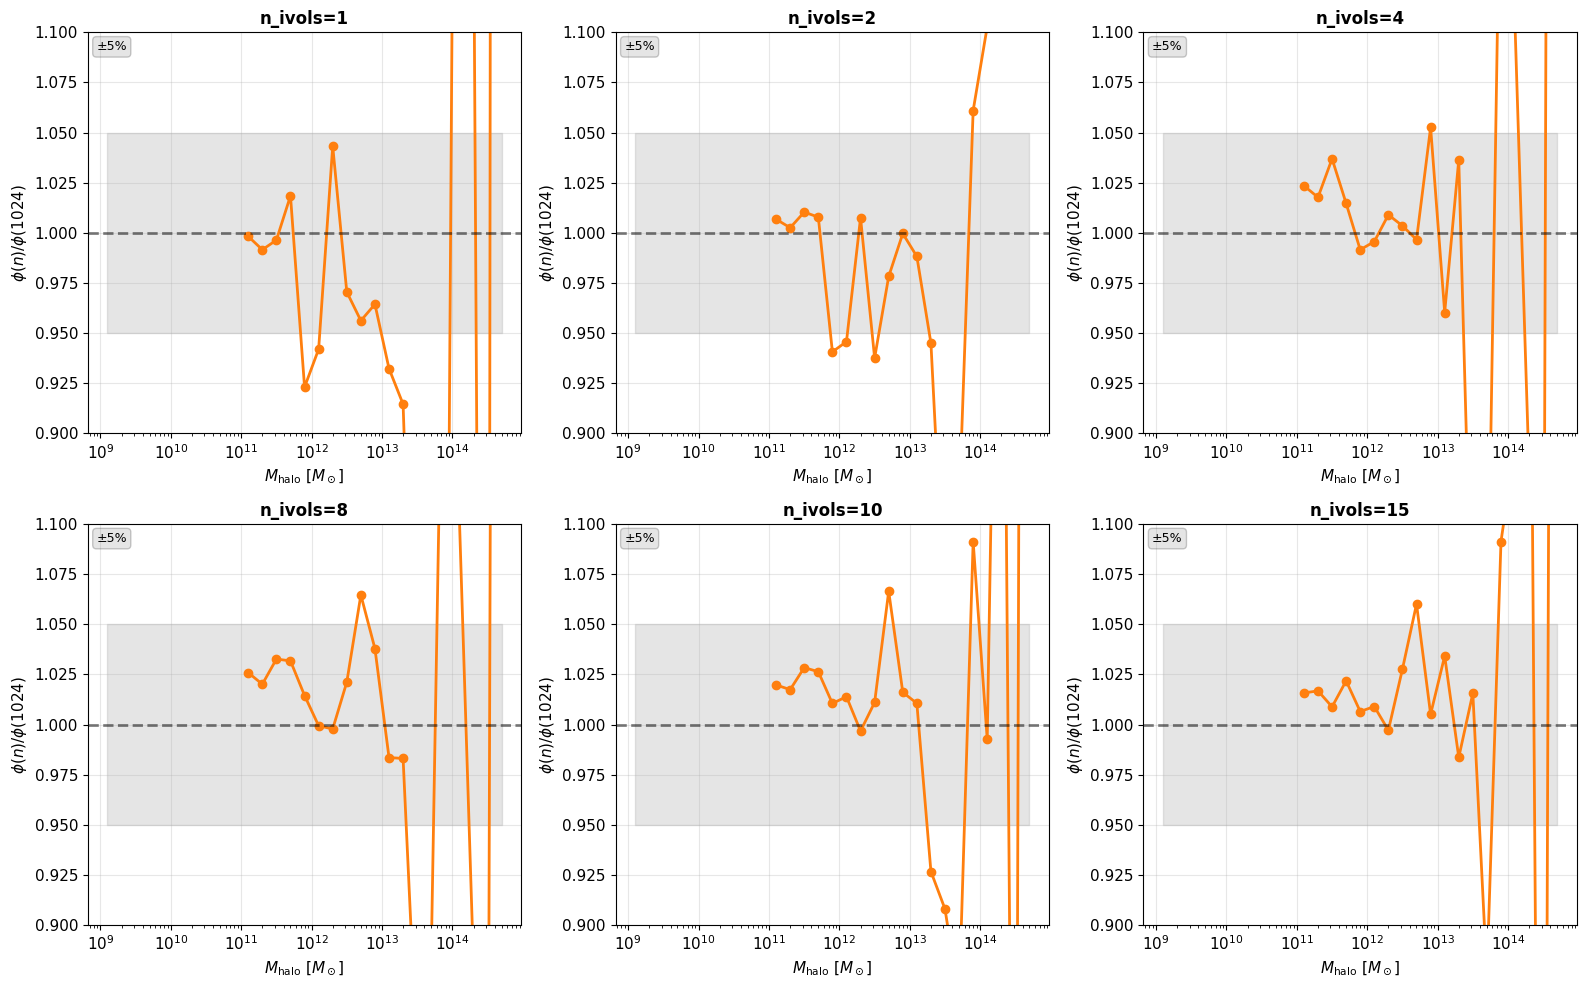

✓ HMF ratio plots generated


In [26]:
# Plot HMF ratio phi(n)/phi(1024) for iz271
if hmf_stats_v3 is not None:
    selected_n_hmf = [1, 2, 4, 8, 10, 15, 20, 30, 50, 100, 200]
    available_n_hmf = sorted(hmf_stats_v3['n_ivols'].unique())
    selected_n_hmf = [n for n in selected_n_hmf if n in available_n_hmf]
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    # Get baseline (n=1024)
    baseline = hmf_stats_v3[hmf_stats_v3['n_ivols'] == 1024].sort_values('log_Mhalo')
    baseline_dict = dict(zip(baseline['log_Mhalo'], baseline['phi_mean']))
    
    # Plot for first 6 selected n_ivols
    for idx, n_val in enumerate(selected_n_hmf[:6]):
        ax = axes[idx]
        
        # Get data for this n
        sub = hmf_stats_v3[hmf_stats_v3['n_ivols'] == n_val].sort_values('log_Mhalo')
        
        # Compute ratio
        M = 10.0 ** sub['log_Mhalo'].values
        ratio = []
        for _, row in sub.iterrows():
            if row['log_Mhalo'] in baseline_dict and baseline_dict[row['log_Mhalo']] > 0:
                r = row['phi_mean'] / baseline_dict[row['log_Mhalo']]
                ratio.append(r)
            else:
                ratio.append(np.nan)
        ratio = np.array(ratio)
        
        ax.semilogx(M, ratio, 'o-', linewidth=2, markersize=6, color='C1')
        ax.axhline(y=1.0, color='k', linestyle='--', linewidth=2, alpha=0.5)
        ax.fill_between(M, 0.95, 1.05, alpha=0.2, color='gray')
        ax.text(0.02, 0.98, '±5%', transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='gray', alpha=0.2))
        
        ax.set_ylim([0.9, 1.1])
        ax.set_xlabel(r'$M_{\rm halo}$ [$M_\odot$]', fontsize=11)
        ax.set_ylabel(r'$\phi(n) / \phi(1024)$', fontsize=11)
        ax.set_title(f'n_ivols={n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('hmf_v3_ratios.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ HMF ratio plots generated")
else:

    print("✗ hmf_stats_v3 not available for plotting")

# 2PCF Analysis - v3 Single Iteration (iz271)

In [46]:
# Load 2PCF data from v3_iter3 (single iteration) for iz271
print(f"Current working directory: {Path.cwd()}")
print(f"repo_root: {repo_root}")

# Load 2PCF data for iz271 from v3_iter3
corr_path_271 = os.path.join(v3_dir, "corr_convergence_iz271.csv")
print(f"Looking for: {corr_path_271}")

if os.path.isfile(corr_path_271):
    corr_271 = pd.read_csv(corr_path_271)
    print(f"✓ Loaded 2PCF v3_iter3 data for iz271")
    print(f"  Shape: {corr_271.shape}")
    print(f"  Unique n_ivols: {sorted(corr_271['n_ivols'].unique())}")
    print(f"  Number of r bins: {corr_271['bin_idx'].nunique()}")
    print(f"  r range: [{corr_271['r'].min():.3f}, {corr_271['r'].max():.2f}]")
else:
    corr_271 = None
    print("✗ No 2PCF v3_iter3 data found for iz271")

Current working directory: /cosma/home/durham/dc-hick2/galform_analysis/examples/ongoing
repo_root: /cosma/home/durham/dc-hick2/galform_analysis
Looking for: /cosma/home/durham/dc-hick2/galform_analysis/convergence_results_v3_iter3/corr_convergence_iz271.csv
✓ Loaded 2PCF v3_iter3 data for iz271
  Shape: (223, 6)
  Unique n_ivols: [1, 2, 4, 8, 10, 15, 20, 30, 50, 100, 200, 1024]
  Number of r bins: 19
  r range: [0.119, 43.77]


In [47]:
# Create corr_grouped from single iteration data (no averaging needed)
# Rename xi -> xi_mean for compatibility with downstream code
if corr_271 is not None:
    corr_grouped = corr_271.copy()
    corr_grouped = corr_grouped.rename(columns={'xi': 'xi_mean'})
    corr_grouped['xi_std'] = 0.0  # No std for single iteration
    corr_grouped['iz'] = 271
    
    print(f"✓ Created corr_grouped from corr_271")
    print(f"  Shape: {corr_grouped.shape}")
    print(f"  Unique n_ivols: {sorted(corr_grouped['n_ivols'].unique())}")
    print(f"  r range: {corr_grouped['r'].min():.3f} - {corr_grouped['r'].max():.2f}")
    print(f"  Columns: {list(corr_grouped.columns)}")
else:
    corr_grouped = None
    print("✗ corr_271 not available")

✓ Created corr_grouped from corr_271
  Shape: (223, 7)
  Unique n_ivols: [1, 2, 4, 8, 10, 15, 20, 30, 50, 100, 200, 1024]
  r range: 0.119 - 43.77
  Columns: ['iz', 'z', 'n_ivols', 'r', 'xi_mean', 'bin_idx', 'xi_std']


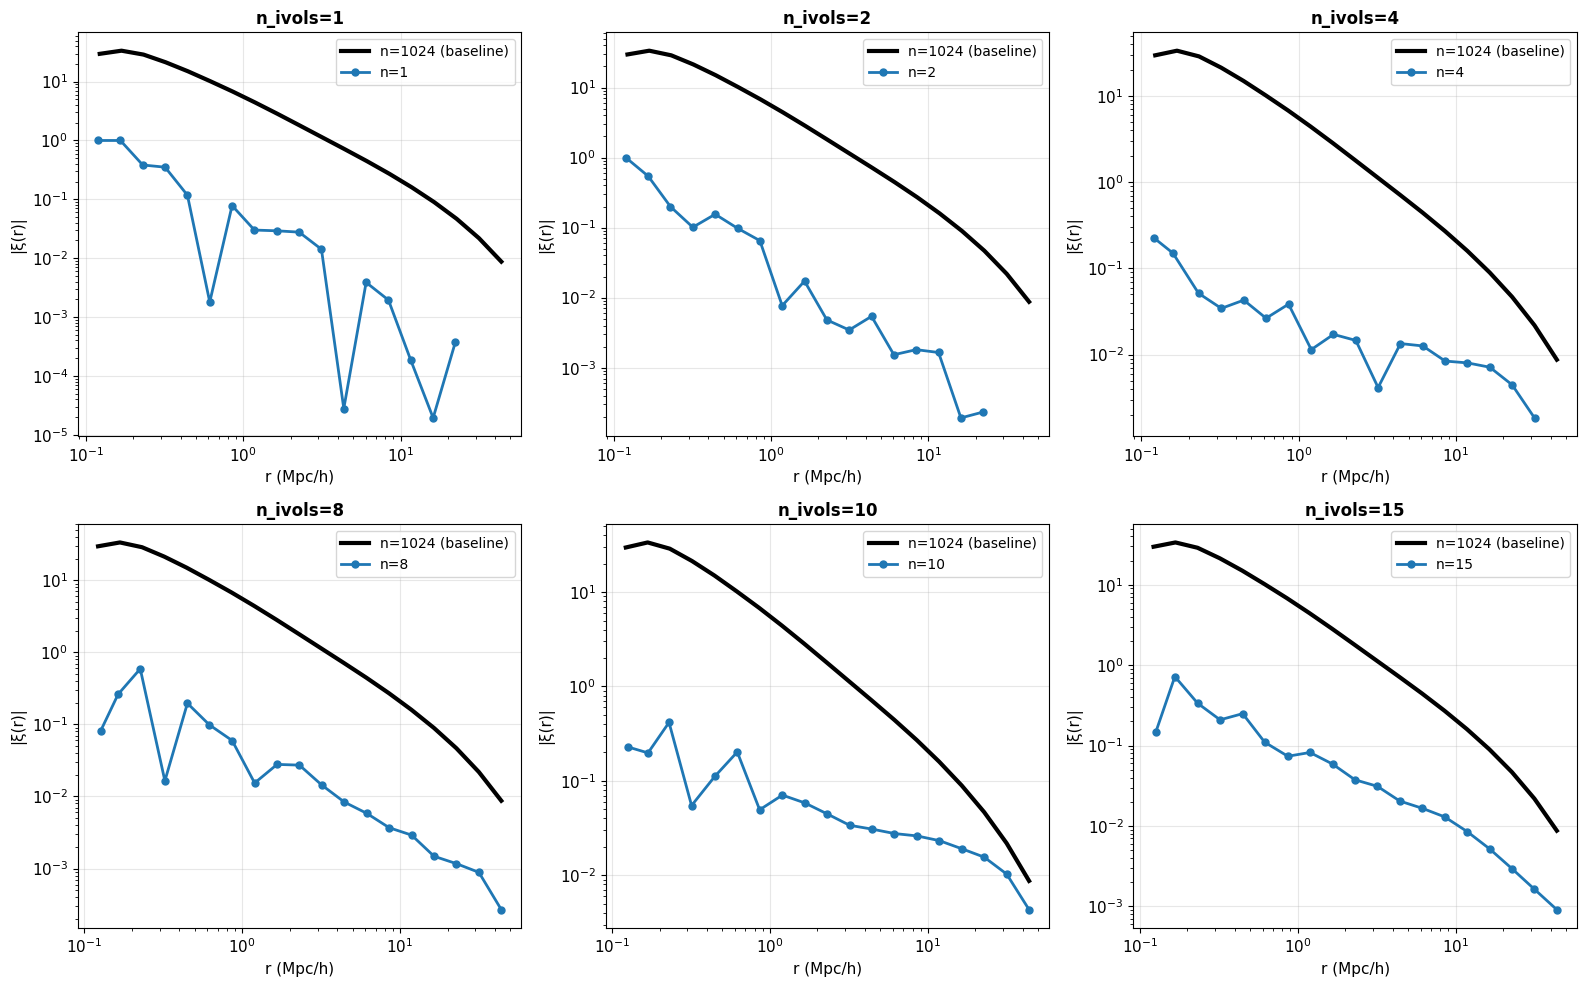

✓ 2PCF overlay plots generated


In [ ]:
# Plot 2PCF overlay with baseline (n_ivols=1024)
if corr_grouped is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    # Select a few n_ivols for clarity
    selected_n = [1, 2, 4, 8, 10, 15, 30, 50]

    for idx, n_val in enumerate(selected_n):
        if idx >= 6:
            break
        ax = axes[idx]
        
        # Plot baseline
        ref_data = corr_grouped[corr_grouped['n_ivols'] == 1024].sort_values('r')
        ax.loglog(ref_data['r'], np.abs(ref_data['xi_mean']), 'k-', linewidth=3, label='n=1024 (baseline)', zorder=10)
        
        # Plot subvolume
        sub_data = corr_grouped[corr_grouped['n_ivols'] == n_val].sort_values('r')
        if len(sub_data) > 0:
            ax.loglog(sub_data['r'], np.abs(sub_data['xi_mean']), 'o-', linewidth=2, label=f'n={n_val}', markersize=5)
        
        ax.set_xlabel('r (Mpc/h)', fontsize=11)
        ax.set_ylabel('|ξ(r)|', fontsize=11)
        ax.set_title(f'n_ivols={n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)

    # Remove extra subplots
    for idx in range(len(selected_n[:6]), 6):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.savefig('corr_v3_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ 2PCF overlay plots generated")
else:
    print("✗ corr_grouped not available for plotting")

In [48]:
# Compute 2PCF scalar metrics (relative errors vs baseline n_ivols=1024)
def corr_scalar_metrics(df, ref_n=1024, r_min=0.5, r_max=10.0):
    """Compute convergence metrics for 2PCF data with scale cuts and clipping."""
    metrics_list = []

    for iz in df['iz'].unique():
        df_iz = df[df['iz'] == iz].copy()
        ref_data = df_iz[df_iz['n_ivols'] == ref_n][['bin_idx', 'r', 'xi_mean']].copy()
        ref_data = ref_data[(ref_data['r'] >= r_min) & (ref_data['r'] <= r_max)]
        ref_data.columns = ['bin_idx', 'r_ref', 'xi_ref']

        for n in sorted(df_iz['n_ivols'].unique()):
            if n == ref_n:
                continue

            sub_data = df_iz[df_iz['n_ivols'] == n][['bin_idx', 'r', 'xi_mean']].copy()
            sub_data.columns = ['bin_idx', 'r_sub', 'xi_sub']

            # Merge on bin_idx only to avoid floating-point mismatches on r
            merged = pd.merge(sub_data, ref_data, on='bin_idx')
            if merged.empty:
                continue
            merged['r'] = merged['r_ref']

            # Keep only bins where baseline is non-zero
            merged = merged[merged['xi_ref'] != 0].copy()
            if merged.empty:
                continue

            merged['rel_err'] = (merged['xi_sub'] - merged['xi_ref']) / np.abs(merged['xi_ref'])
            merged['rel_err_clipped'] = np.clip(merged['rel_err'], -5, 5)
            merged['abs_rel_err'] = np.abs(merged['rel_err'])
            merged['abs_rel_err_clipped'] = np.abs(merged['rel_err_clipped'])

            merged['log_ratio'] = np.log10(np.abs(merged['xi_sub']) / np.abs(merged['xi_ref']))
            merged['log_ratio_clipped'] = np.clip(merged['log_ratio'], -1, 1)

            merged['abs_diff'] = merged['xi_sub'] - merged['xi_ref']
            merged['abs_diff_abs'] = np.abs(merged['abs_diff'])

            # Aggregates
            weights = np.abs(merged['xi_ref'])
            mean_rel_err = merged['rel_err'].mean()
            mean_abs_rel_err = merged['abs_rel_err'].mean()
            median_abs_rel_err = merged['abs_rel_err'].median()
            max_abs_rel_err = merged['abs_rel_err'].max()
            rmse_log = np.sqrt((merged['log_ratio'] ** 2).mean())

            mean_abs_rel_err_w = np.average(merged['abs_rel_err'], weights=weights) if weights.sum() > 0 else np.nan
            mean_abs_rel_err_clipped = merged['abs_rel_err_clipped'].mean()
            max_abs_rel_err_clipped = merged['abs_rel_err_clipped'].max()
            rmse_log_clipped = np.sqrt((merged['log_ratio_clipped'] ** 2).mean())

            abs_diff_mean = merged['abs_diff'].mean()
            abs_diff_mean_abs = merged['abs_diff_abs'].mean()
            abs_diff_mean_abs_w = np.average(merged['abs_diff_abs'], weights=weights) if weights.sum() > 0 else np.nan

            metrics_list.append({
                'iz': iz,
                'n_ivols': n,
                'mean_rel_err': f"{mean_rel_err:.2g}",
                'mean_abs_rel_err': f"{mean_abs_rel_err:.2g}",
                'median_abs_rel_err': f"{median_abs_rel_err:.2g}",
                'max_abs_rel_err': f"{max_abs_rel_err:.2g}",
                'rmse_log10_ratio': f"{rmse_log:.2g}",
                'mean_abs_rel_err_weighted': f"{mean_abs_rel_err_w:.2g}" if not np.isnan(mean_abs_rel_err_w) else "nan",
                'mean_abs_rel_err_clipped': f"{mean_abs_rel_err_clipped:.2g}",
                'max_abs_rel_err_clipped': f"{max_abs_rel_err_clipped:.2g}",
                'rmse_log10_ratio_clipped': f"{rmse_log_clipped:.2g}",
                'abs_diff_mean': f"{abs_diff_mean:.2g}",
                'abs_diff_mean_abs': f"{abs_diff_mean_abs:.2g}",
                'abs_diff_mean_abs_weighted': f"{abs_diff_mean_abs_w:.2g}" if not np.isnan(abs_diff_mean_abs_w) else "nan",
            })

    return pd.DataFrame(metrics_list)

# Also compute numeric version for plotting
def corr_scalar_metrics_numeric(df, ref_n=1024, r_min=0.5, r_max=10.0):
    """Compute convergence metrics for 2PCF data (returning numeric values)."""
    metrics_list = []

    for iz in df['iz'].unique():
        df_iz = df[df['iz'] == iz].copy()
        ref_data = df_iz[df_iz['n_ivols'] == ref_n][['bin_idx', 'r', 'xi_mean']].copy()
        ref_data = ref_data[(ref_data['r'] >= r_min) & (ref_data['r'] <= r_max)]
        ref_data.columns = ['bin_idx', 'r_ref', 'xi_ref']

        for n in sorted(df_iz['n_ivols'].unique()):
            if n == ref_n:
                continue

            sub_data = df_iz[df_iz['n_ivols'] == n][['bin_idx', 'r', 'xi_mean']].copy()
            sub_data.columns = ['bin_idx', 'r_sub', 'xi_sub']

            merged = pd.merge(sub_data, ref_data, on='bin_idx')
            if merged.empty:
                continue
            merged['r'] = merged['r_ref']
            merged = merged[merged['xi_ref'] != 0].copy()
            if merged.empty:
                continue

            merged['rel_err'] = (merged['xi_sub'] - merged['xi_ref']) / np.abs(merged['xi_ref'])
            merged['rel_err_clipped'] = np.clip(merged['rel_err'], -5, 5)
            merged['abs_rel_err'] = np.abs(merged['rel_err'])
            merged['abs_rel_err_clipped'] = np.abs(merged['rel_err_clipped'])
            merged['log_ratio'] = np.log10(np.abs(merged['xi_sub']) / np.abs(merged['xi_ref']))
            merged['log_ratio_clipped'] = np.clip(merged['log_ratio'], -1, 1)
            merged['abs_diff'] = merged['xi_sub'] - merged['xi_ref']
            merged['abs_diff_abs'] = np.abs(merged['abs_diff'])

            weights = np.abs(merged['xi_ref'])
            metrics_list.append({
                'iz': iz,
                'n_ivols': n,
                'mean_rel_err': merged['rel_err'].mean(),
                'mean_abs_rel_err': merged['abs_rel_err'].mean(),
                'median_abs_rel_err': merged['abs_rel_err'].median(),
                'max_abs_rel_err': merged['abs_rel_err'].max(),
                'rmse_log10_ratio': np.sqrt((merged['log_ratio'] ** 2).mean()),
                'mean_abs_rel_err_weighted': np.average(merged['abs_rel_err'], weights=weights) if weights.sum() > 0 else np.nan,
                'mean_abs_rel_err_clipped': merged['abs_rel_err_clipped'].mean(),
                'max_abs_rel_err_clipped': merged['abs_rel_err_clipped'].max(),
                'rmse_log10_ratio_clipped': np.sqrt((merged['log_ratio_clipped'] ** 2).mean()),
                'abs_diff_mean': merged['abs_diff'].mean(),
                'abs_diff_mean_abs': merged['abs_diff_abs'].mean(),
                'abs_diff_mean_abs_weighted': np.average(merged['abs_diff_abs'], weights=weights) if weights.sum() > 0 else np.nan,
            })

    return pd.DataFrame(metrics_list)

# Compute metrics for v3 2PCF data
if corr_grouped is not None:
    corr_metrics_v3 = corr_scalar_metrics(corr_grouped, ref_n=1024)
    print("2PCF Convergence Metrics (v3 single iteration, baseline n_ivols=1024, 0.5<=r<=10 Mpc/h):")
    print(corr_metrics_v3)

    corr_stats_v3 = corr_scalar_metrics_numeric(corr_grouped, ref_n=1024)
    print("\n✓ Metrics computed for plotting")
else:
    corr_metrics_v3 = None
    corr_stats_v3 = None
    print("✗ corr_grouped not available")

2PCF Convergence Metrics (v3 single iteration, baseline n_ivols=1024, 0.5<=r<=10 Mpc/h):
     iz  n_ivols mean_rel_err mean_abs_rel_err median_abs_rel_err  \
0   271        1           -1                1                  1   
1   271        2           -1                1                  1   
2   271        4        -0.99             0.99               0.99   
3   271        8        -0.99             0.99               0.99   
4   271       10        -0.96             0.96               0.98   
5   271       15        -0.98             0.98               0.98   
6   271       20        -0.94             0.94               0.96   
7   271       30        -0.93             0.93               0.95   
8   271       50        -0.86             0.86                0.9   
9   271      100        -0.81             0.81               0.85   
10  271      200         -0.6              0.6               0.69   

   max_abs_rel_err rmse_log10_ratio mean_abs_rel_err_weighted  \
0                

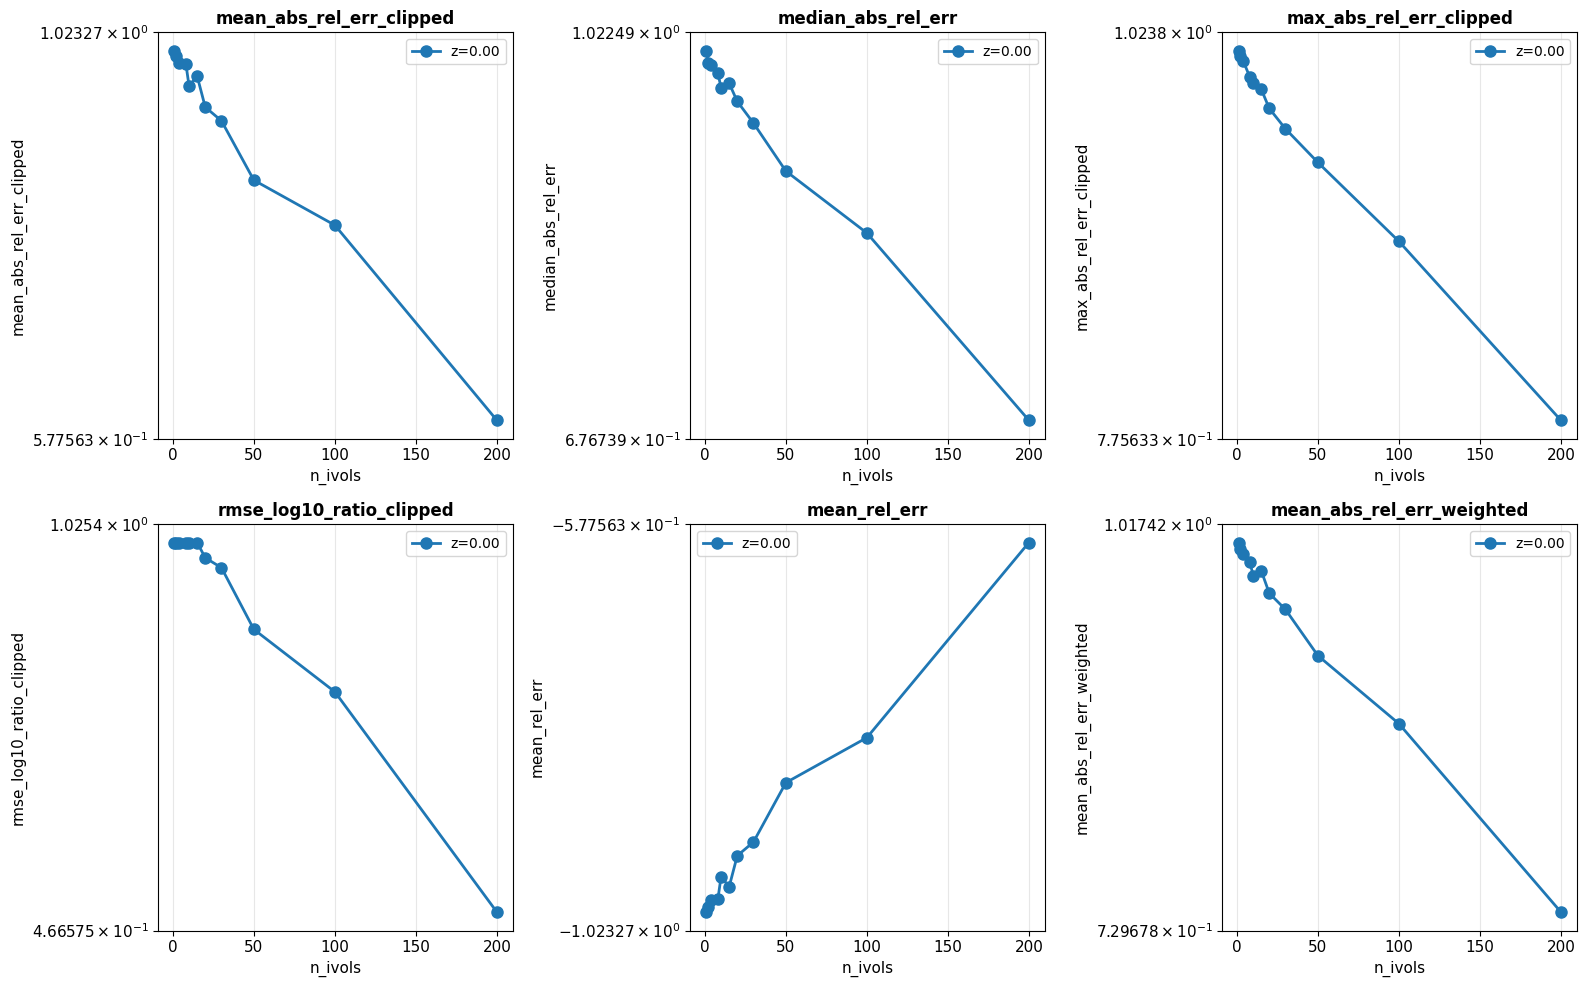

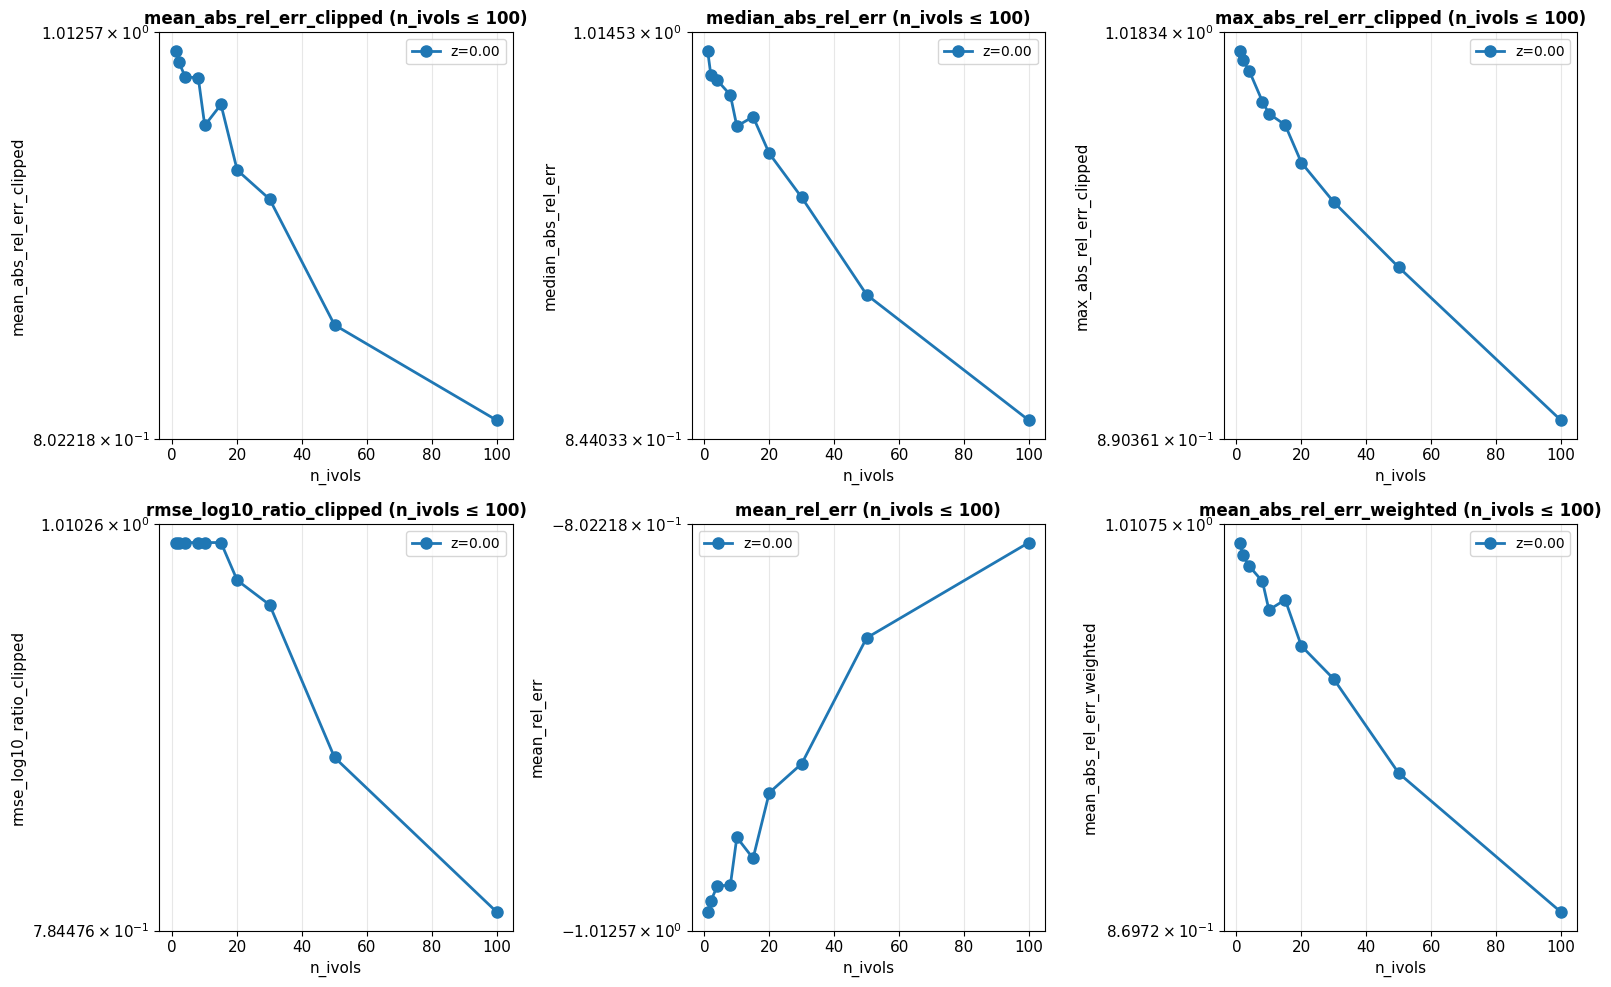

✓ 2PCF metrics plots generated


In [39]:
# Plot 2PCF convergence metrics vs n_ivols
z_271 = get_snapshot_redshift("iz271")

if corr_stats_v3 is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    metric_cols = [
        'mean_abs_rel_err_clipped',
        'median_abs_rel_err',
        'max_abs_rel_err_clipped',
        'rmse_log10_ratio_clipped',
        'mean_rel_err',
        'mean_abs_rel_err_weighted',
    ]

    for idx, metric in enumerate(metric_cols):
        ax = axes[idx]

        data = corr_stats_v3[corr_stats_v3['iz'] == 271]
        z_label = f"z={z_271:.2f}"
        ax.plot(data['n_ivols'], data[metric], marker='o', label=z_label, linewidth=2, markersize=8)

        ax.set_xlabel('n_ivols', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_yscale('symlog')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('corr_v3_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Zoomed view for small n_ivols
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for idx, metric in enumerate(metric_cols):
        ax = axes[idx]

        data = corr_stats_v3[(corr_stats_v3['iz'] == 271) & (corr_stats_v3['n_ivols'] <= 100)]
        z_label = f"z={z_271:.2f}"
        ax.plot(data['n_ivols'], data[metric], marker='o', label=z_label, linewidth=2, markersize=8)

        ax.set_xlabel('n_ivols', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(f"{metric} (n_ivols ≤ 100)", fontsize=12, fontweight='bold')
        ax.set_yscale('symlog')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('corr_v3_metrics_small.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ 2PCF metrics plots generated")
else:
    print("✗ corr_stats_v3 not available for plotting")

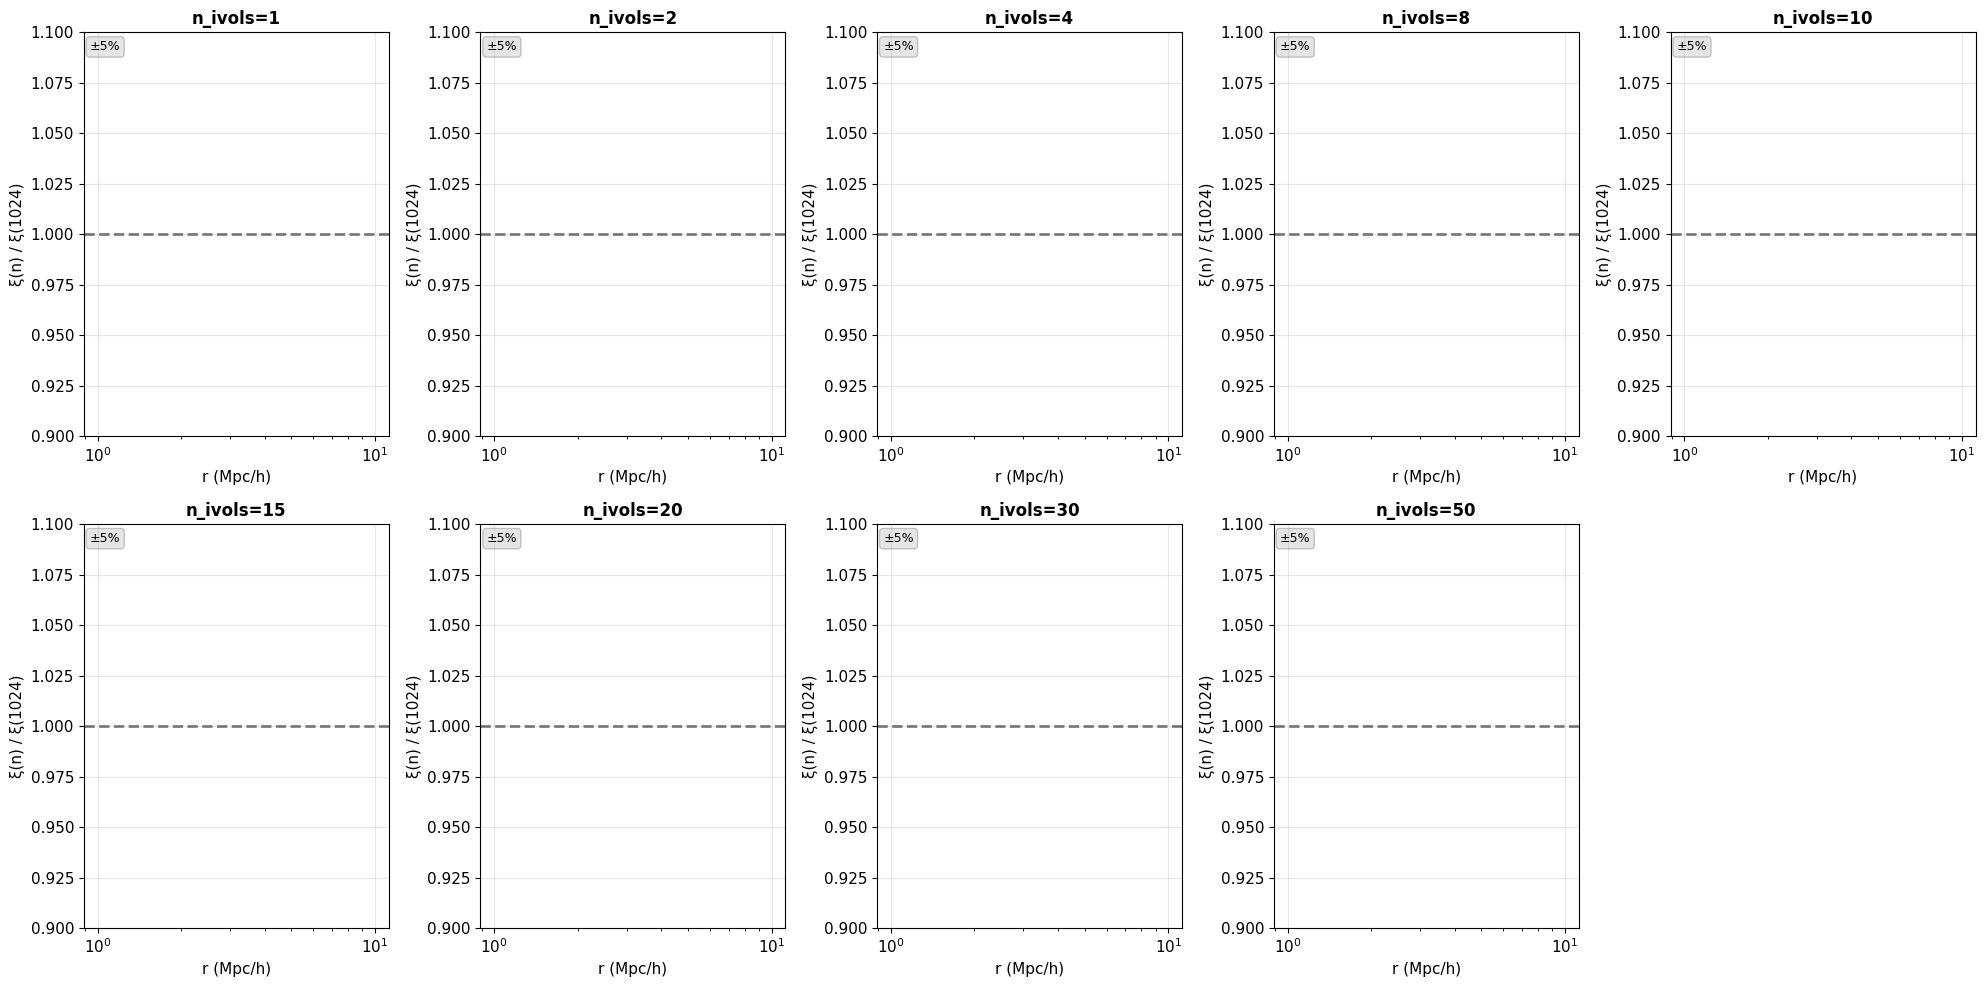

✓ 2PCF ratio plots generated


In [34]:
# Plot 2PCF ratio xi(n)/xi(1024)
if corr_grouped is not None:
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.flatten()

    selected_n = [1, 2, 4, 8, 10, 15, 20, 30, 50, 100]  # Only plot available n_ivols

    for idx, n_val in enumerate(selected_n):
        ax = axes[idx]
        
        # Get baseline
        ref_data = corr_grouped[corr_grouped['n_ivols'] == 1024].sort_values('r')
        sub_data = corr_grouped[corr_grouped['n_ivols'] == n_val].sort_values('r')
        
        if len(sub_data) > 0 and len(ref_data) > 0:
            # Merge to compute ratio
            merged = pd.merge(sub_data[['bin_idx', 'r', 'xi_mean']], 
                             ref_data[['bin_idx', 'r', 'xi_mean']], 
                             on=['bin_idx', 'r'], suffixes=('_sub', '_ref'))
            merged = merged[merged['xi_mean_ref'] != 0].copy()
            merged['ratio'] = merged['xi_mean_sub'] / merged['xi_mean_ref']
            merged = merged.sort_values('r')
            
            ax.semilogx(merged['r'], merged['ratio'], 'o-', linewidth=2, markersize=6)
            ax.axhline(y=1, color='k', linestyle='--', linewidth=2, alpha=0.5)
            ax.fill_between(merged['r'], 0.95, 1.05, alpha=0.2, color='gray')
            # Add legend entry for the band
            ax.text(0.02, 0.98, '±5%', transform=ax.transAxes, fontsize=9, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='gray', alpha=0.2))
            ax.set_ylim([0.9, 1.1])
        
        ax.set_xlabel('r (Mpc/h)', fontsize=11)
        ax.set_ylabel('ξ(n) / ξ(1024)', fontsize=11)
        ax.set_title(f'n_ivols={n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

    # Hide the extra subplot
    axes[-1].set_visible(False)

    plt.tight_layout()
    plt.savefig('corr_v3_ratios.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ 2PCF ratio plots generated")
else:
    print("✗ corr_grouped not available for plotting")

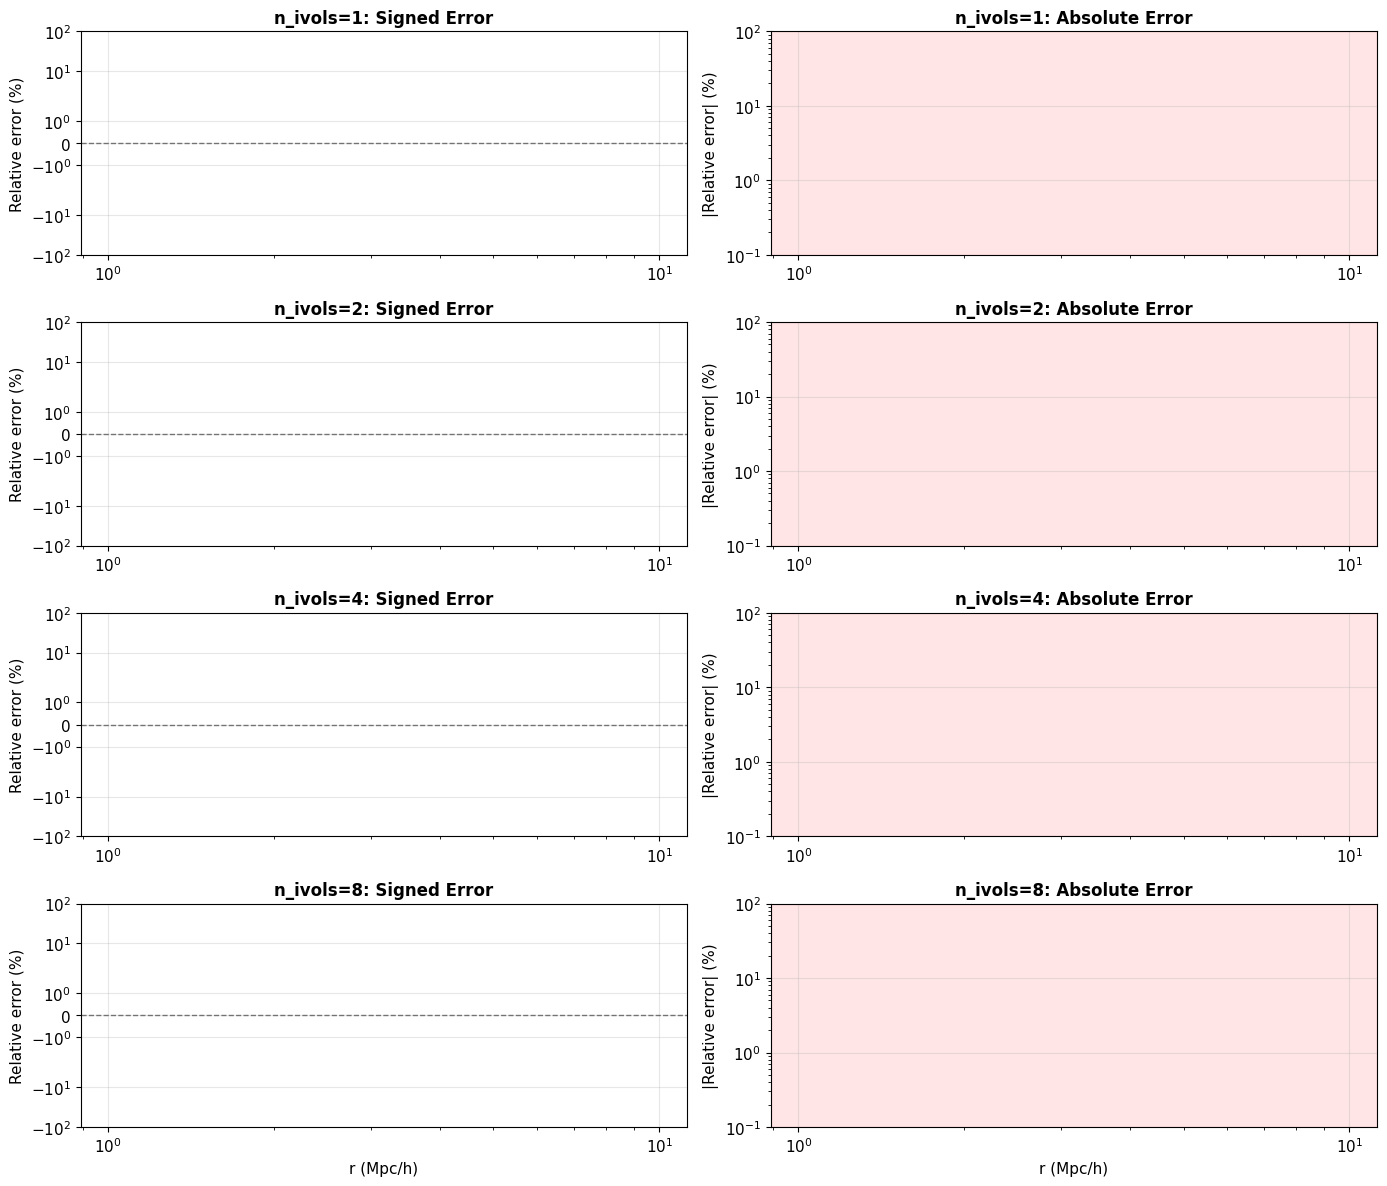

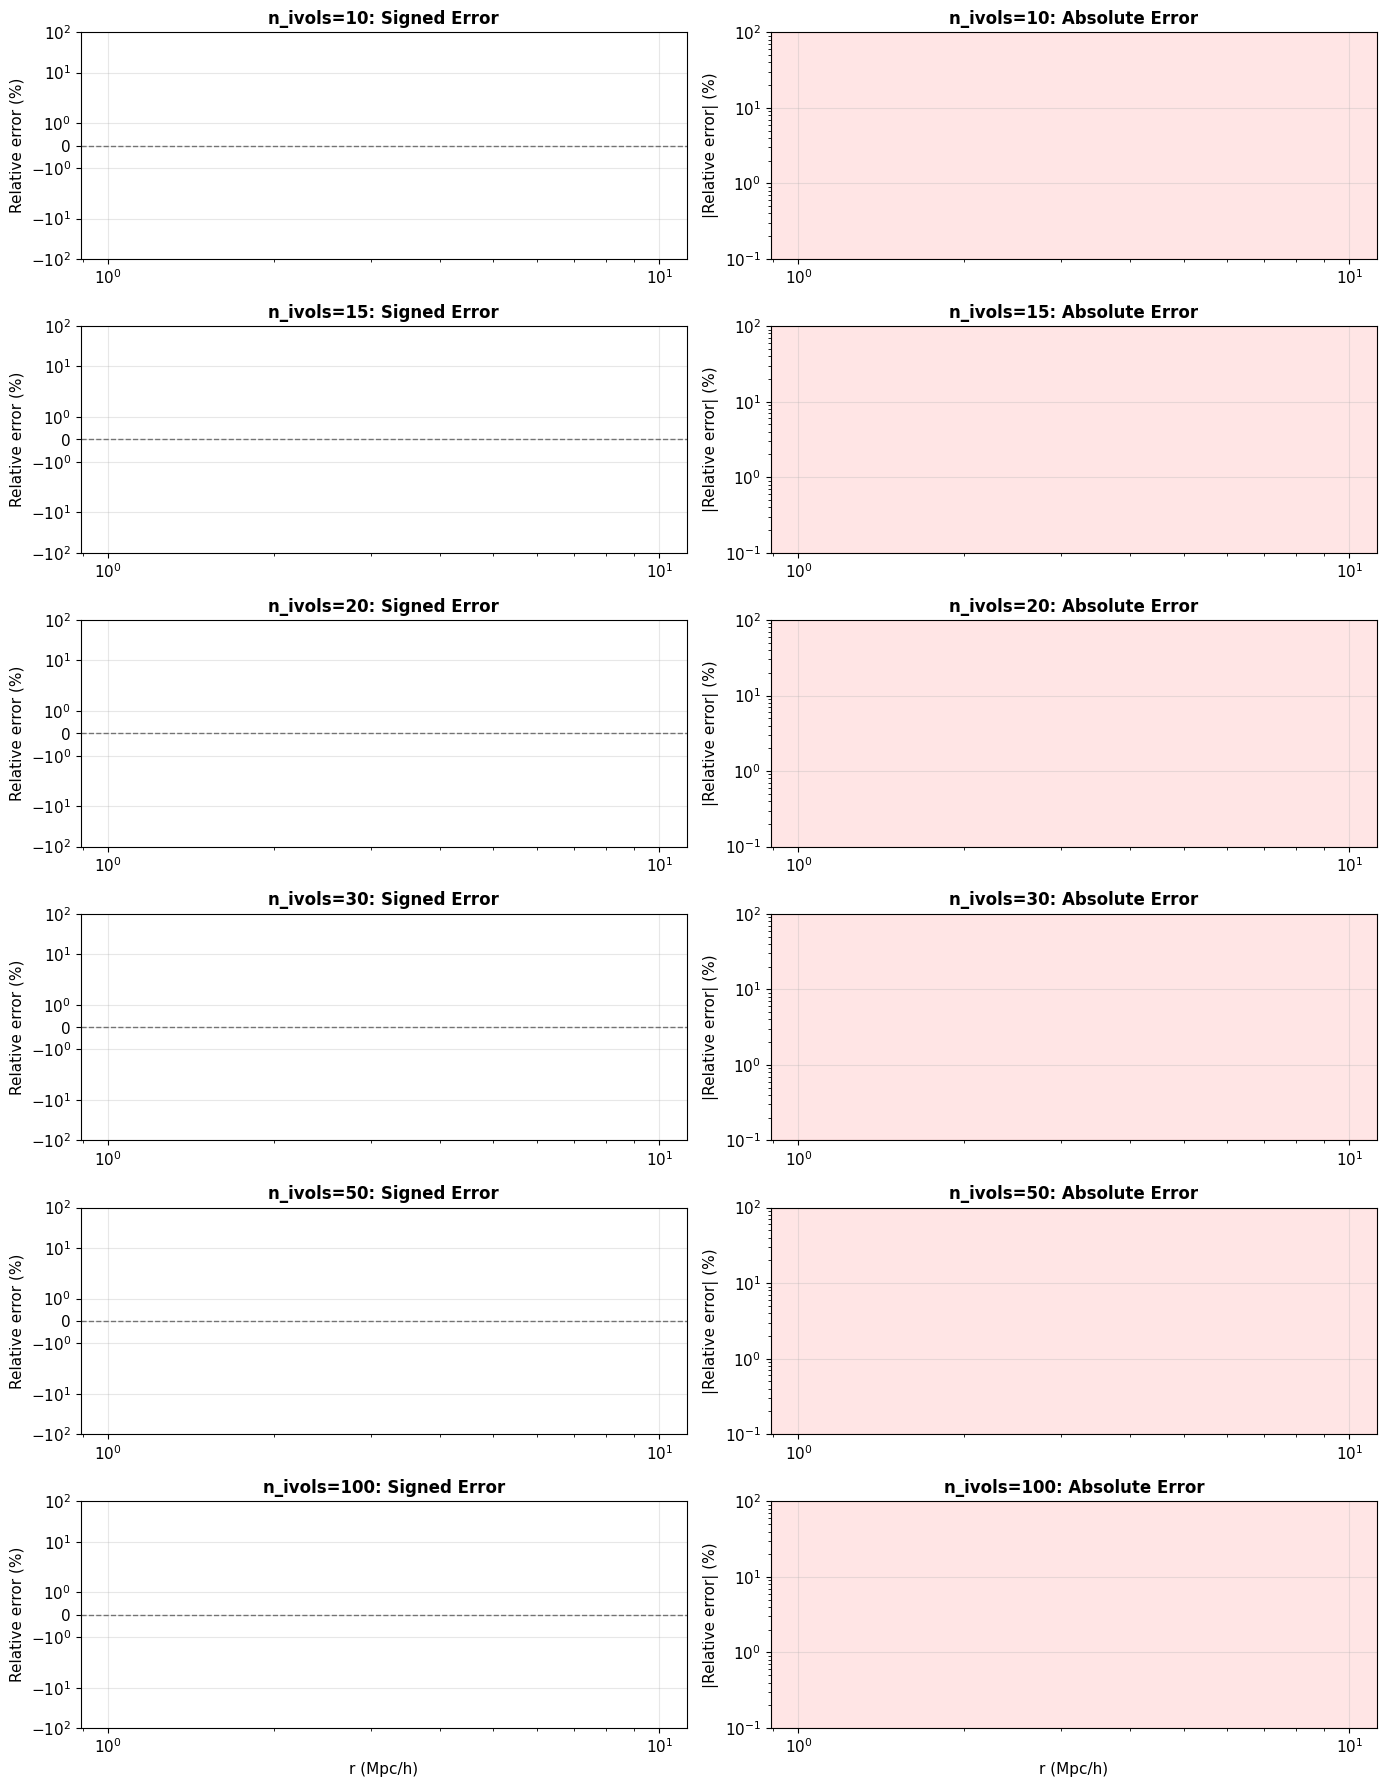

✓ 2PCF error vs scale plots generated


In [35]:
# Plot error vs scale for selected n_ivols
def plot_corr_error_vs_scale(df, selected_n_vals, ref_n=1024):
    """Visualize 2PCF convergence behavior across scale range."""
    fig, axes = plt.subplots(len(selected_n_vals), 2, figsize=(14, 3*len(selected_n_vals)))
    if len(selected_n_vals) == 1:
        axes = axes.reshape(1, -1)
    
    ref_data = df[df['n_ivols'] == ref_n].sort_values('r')
    
    for row, n_val in enumerate(selected_n_vals):
        sub_data = df[df['n_ivols'] == n_val].sort_values('r')
        
        if len(sub_data) > 0:
            # Merge on bin_idx and r
            merged = pd.merge(sub_data[['bin_idx', 'r', 'xi_mean']], 
                             ref_data[['bin_idx', 'r', 'xi_mean']], 
                             on=['bin_idx', 'r'], suffixes=('_sub', '_ref'))
            merged = merged[merged['xi_mean_ref'] != 0].copy()
            merged['rel_err'] = (merged['xi_mean_sub'] - merged['xi_mean_ref']) / np.abs(merged['xi_mean_ref'])
            merged['abs_rel_err'] = np.abs(merged['rel_err'])
            
            # Left panel: signed error (symlog)
            ax = axes[row, 0]
            ax.semilogx(merged['r'], merged['rel_err'] * 100, 'o-', linewidth=2, markersize=5, color='C0')
            ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            ax.set_ylabel('Relative error (%)', fontsize=11)
            ax.set_title(f'n_ivols={n_val}: Signed Error', fontsize=12, fontweight='bold')
            ax.set_yscale('symlog')
            ax.grid(True, alpha=0.3)
            ax.set_ylim([-100, 100])
            
            # Right panel: absolute error (log)
            ax = axes[row, 1]
            ax.loglog(merged['r'], merged['abs_rel_err'] * 100, 'o-', linewidth=2, markersize=5, color='C1')
            # Add background region
            r_min, r_max = merged['r'].min(), merged['r'].max()
            ax.axhspan(0.1, 100, xmin=0, xmax=1, alpha=0.1, color='red', zorder=0)
            ax.set_ylabel('|Relative error| (%)', fontsize=11)
            ax.set_title(f'n_ivols={n_val}: Absolute Error', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0.1, 100])
    
    axes[len(selected_n_vals)-1, 0].set_xlabel('r (Mpc/h)', fontsize=11)
    axes[len(selected_n_vals)-1, 1].set_xlabel('r (Mpc/h)', fontsize=11)
    
    plt.tight_layout()
    return fig

if corr_grouped is not None:
    # Plot error vs scale for small n_ivols
    selected_n = [1, 2, 4, 8]
    fig = plot_corr_error_vs_scale(corr_grouped, selected_n, ref_n=1024)
    plt.savefig('corr_v3_error_vs_scale_small.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Also for larger n_ivols
    selected_n = [10, 15, 20, 30, 50, 100]
    fig = plot_corr_error_vs_scale(corr_grouped, selected_n, ref_n=1024)
    plt.savefig('corr_v3_error_vs_scale_large.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ 2PCF error vs scale plots generated")
else:
    print("✗ corr_grouped not available for plotting")

## HMF Convergence Analysis (iz271)